In [3]:
setwd("/data2/core-med1/nhadizad/nastaran/Xenotransplant/global/CLR/NEW_CLR/Rounds_v2_CLR_8/Cell_states/Ref_Standard/Myeloids (baboon)/")

library(stringr) #deal with string
options(stringsAsFactors = FALSE)

# --- Load Libraries without warnings/messages ---
quiet_library <- function(pkg) suppressWarnings(suppressMessages(library(pkg, character.only = TRUE)))

pkgs <- c(
  "dplyr", "zCompositions", "compositions", "reshape2", "ggplot2",
  "ggpubr", "tidyr", "tibble", "stringr", "purrr"
)

invisible(lapply(pkgs, quiet_library))

options(stringsAsFactors = FALSE)
options(future.globals.maxSize = 10 * 1024^3)



In [4]:

# 1. Load configuration variables
metadata_file <- "metadata_for_clr_Myeloids_baboon.csv"
sample_col    <- "Sample_ID"
celltype_col  <- "cell_states"
condition_col <- "Condition_subsets"
ref_condition <- "Standard protocol"

# Load metadata (assuming index=False was used in Python)
meta <- read.csv(metadata_file, check.names = FALSE)



In [5]:
# ---------------------------
# 2. Collapse counts per cell state, sample, and condition
# ---------------------------
# This aggregates the data into a table suitable for downstream analysis
prop.coarse <- meta %>%
  group_by(cell_states, Sample_ID, Condition_subsets) %>%
  summarise(count = n(), .groups = "drop")

# ---------------------------
# 3. Generate count and proportion matrices
# ---------------------------
# These functions convert the long format to a matrix with samples as rows, cell states as columns

# Helper: Count matrix
get.count.matrix <- function(props, celltype_col, value_col) {
  frm <- as.formula(paste("Sample_ID", celltype_col, sep = "~"))
  ct <- reshape2::acast(props, frm, value.var = value_col, fun.aggregate = mean, fill = 0)
  return(ct)
}

# Helper: Proportion matrix (row-normalized, NO imputation)
get.proportion.matrix <- function(prop.coarse, celltype_col, pseudocount = 0,
                                 value_col = "proportion", impute_zeros = FALSE) {
  ct <- get.count.matrix(prop.coarse, celltype_col, value_col)
  ct <- ct + pseudocount # Add pseudocount if desired, but here 0 by default
  ct <- ct / rowSums(ct)
  return(ct)
}

# Create matrices for downstream analysis
prop_matrix <- get.proportion.matrix(prop.coarse, celltype_col = "cell_states", value_col = "count")
count_matrix <- get.count.matrix(prop.coarse, celltype_col = "cell_states", value_col = "count")

# ---------------------------
# 4. Prepare the analysis DataFrame (Simplified Factor Setup)
# ---------------------------
prop_df <- as.data.frame(prop_matrix) %>%
  tibble::rownames_to_column("Sample_ID") %>%
  left_join(distinct(meta, Sample_ID, Condition_subsets), by = "Sample_ID")
prop_df$Condition_subsets <- trimws(prop_df$Condition_subsets) # Remove whitespace

# DO NOT set the factor levels here, let the loop handle it
# cond_levels <- c("Standard protocol", "Extended protocol", "Prematurely terminated", "PCMV", "Rejection", "Control")
# prop_df$Condition_subsets <- factor(prop_df$Condition_subsets, levels = cond_levels) # REMOVE THIS


# ---------------------------
# 5. Differential abundance function (CLR + linear model)
# ---------------------------
# The CRITICAL CHANGE (compared to previous buggy code):  
# Always ensure the reference group is explicitly set using `relevel()` INSIDE the function (or right before calling it!)
# This ensures that the reference group for each comparison is "Standard protocol", not whatever comes first alphabetically.

# ---------------------------
# 5. Differential abundance function (CLR + linear model) - FINAL CORRECTED VERSION
# ---------------------------
# This function relies ENTIRELY on the Condition factor being correctly 
# ordered (Reference as Level 1) BEFORE it is passed in.

da.by.covariate <- function(ct, celltype, condition_vec) {
    
    # Check if condition_vec is an ordered factor and stop if not (good practice)
    if (!is.factor(condition_vec) || levels(condition_vec)[1] != ref_condition) {
        stop("condition_vec must be a factor with the reference condition as the first level.")
    }

    Z <- compositions::clr(compositions::acomp(ct))
    data <- data.frame(
        abundance = Z[, celltype],
        proportion = ct[, celltype],
        Condition = condition_vec # This is the pre-ordered factor!
    )
    
    # *** CRITICAL: REMOVED THE CONFLICTING relevel(factor(...)) HERE ***
    # data$Condition <- relevel(factor(data$Condition), ref = ref_condition) 
    
    m <- lm(abundance ~ Condition, data = data)
    smr <- t(coef(summary(m))[2, ]) # Effect size for the non-reference group (Level 2 vs Level 1)

    m2 <- lm(proportion ~ Condition, data = data)
    smr2 <- t(coef(summary(m2))[2, ])
    colnames(smr2) <- paste("prop", colnames(smr2), sep = "_")

    mean.prop <- mean(data$proportion, na.rm = TRUE)
    mean.prop.ctrl <- coef(m2)[1] # Intercept is the mean prop of the reference level (Level 1)

    return(data.frame(smr, smr2, mean.prop, mean.prop.ctrl, check.names = FALSE))
}

# ---------------------------
# 6. Loop through all conditions - CRITICAL FIX
# ---------------------------
conditions_to_test <- setdiff(unique(prop_df$Condition_subsets), ref_condition)
all_results <- list()

for (cond in conditions_to_test) {
  selected <- prop_df %>%
    filter(Condition_subsets %in% c(ref_condition, cond)) %>%
    filter(Sample_ID %in% rownames(count_matrix)[rowSums(count_matrix) >= 10])

  # --- CRITICAL FIX: Explicitly create factor with ONLY 2 levels (Ref first) ---
  selected$Condition_subsets_factor <- factor(
    selected$Condition_subsets, 
    levels = c(ref_condition, cond)
  )
  # --------------------------------------------------------------------------

  # Keep only the cell state columns
  cell_states <- setdiff(colnames(selected), c("Sample_ID", "Condition_subsets", "Condition_subsets_factor"))
  
  results <- lapply(cell_states, function(cs) {
    da.by.covariate(
      selected[, cell_states, drop = FALSE],
      celltype = cs,
      condition_vec = selected$Condition_subsets_factor # Pass the explicitly ordered factor
    )
  })
  
  results <- do.call(rbind, results)
  rownames(results) <- cell_states
  all_results[[cond]] <- results
}
# ---------------------------
# 7. Combine results into one table, adjust FDR
# ---------------------------
results_df <- imap_dfr(all_results, ~ {
  data.frame(
    Condition = .y,
    CellType = rownames(.x),
    PValue = .x[, "Pr(>|t|)"],
    EffectSize = .x[, "Estimate"],
    FoldChange = exp(.x[, "Estimate"]),
    MeanPropControl = .x[, "mean.prop.ctrl"],
    stringsAsFactors = FALSE
  )
}) %>%
  group_by(Condition) %>%
  mutate(FDR = p.adjust(PValue, method = "BH")) %>%
  ungroup()
write.csv(results_df, "CLR_Myeloids_baboon_cellstates_ref_Standard.csv", row.names = FALSE)


In [6]:
our_fill_scale_gradient2 <- scale_fill_gradient2(
  limits = c(-1, 1),
  # Use the 'squish' transformer to force out-of-bounds values to the limit colors
  oob = scales::squish, 
  high = "#FF6600",   # orange
  mid = "white",
  low = "#6699FF"     # blue
)

flipx45 <- theme(axis.text.x = element_text(angle = 45, hjust = 1))

axis_format <- theme(
  axis.text.x = element_text(face = "bold"),
  axis.text.y = element_text(face = "bold"),
  axis.title.x = element_text(face = "bold"),
  axis.title.y = element_text(face = "bold")
)



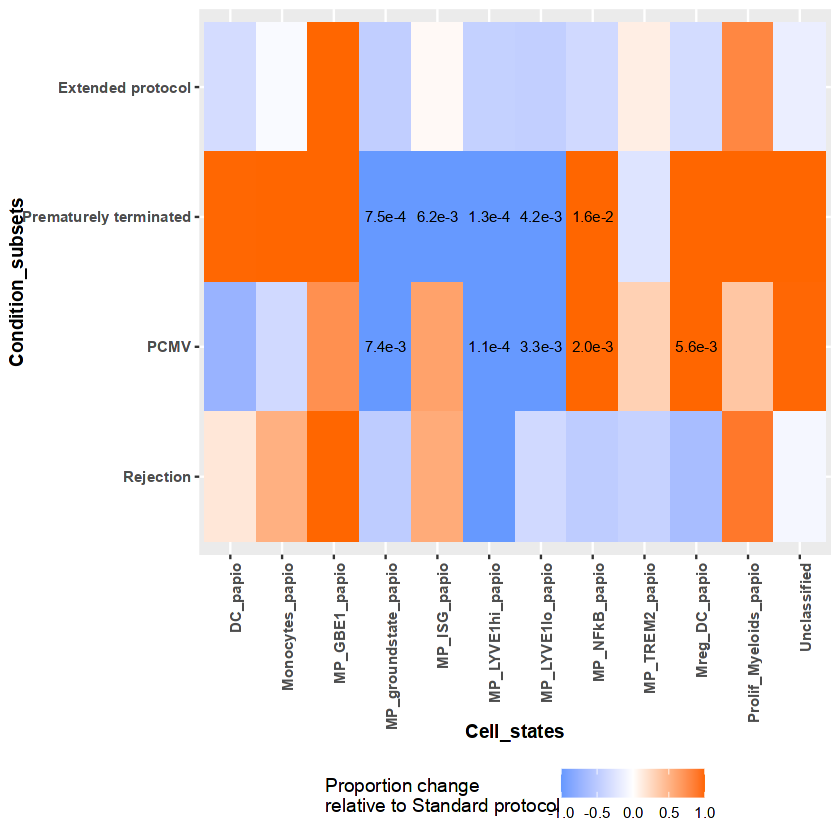

In [7]:

results_df$FDR_plot <- results_df$FDR


# Define the desired order of conditions
condition_order <- c( "Rejection","PCMV", "Prematurely terminated", "Extended protocol", "Control")

# Convert Condition to factor with specified levels before plotting
results_df$Condition <- factor(results_df$Condition, levels = condition_order)

# Now create the plot with the ordered conditions
p1 <- ggplot(results_df, aes(x = CellType, y = Condition, fill = EffectSize)) +
  geom_tile() +
  our_fill_scale_gradient2 +
  labs(
    y = "Condition_subsets",
    x = "Cell_states",
    fill = "Proportion change\nrelative to Standard protocol"
  ) +
  theme(
    legend.position = "bottom",
    axis.text.x = element_text(angle = 90, hjust = 1, face = "bold"),
    axis.text.y = element_text(face = "bold"),
    axis.title.x = element_text(face = "bold"),
    axis.title.y = element_text(face = "bold")
  ) +
  # Add p-value for significant cells only
  geom_text(
    data = subset(results_df, FDR_plot < 0.05),
    aes(label = gsub("e-0", "e-", formatC(PValue, format = "e", digits = 1))),
    color = "black", size = 3
  )

# Save with reduced height
# ggsave("p1_heatmap_plot.pdf", plot = p1, width = 6, height = 4.3, units = "in")

ggsave("heatmap_Myeloids_baboon_states_ref_Standard.pdf", plot = p1, width = 6, height = 4.3, units = "in", dpi = 300)
p1




In [1]:
# 1) Convert counts → per-sample proportions
prop_from_counts <- sweep(count_matrix, 1, rowSums(count_matrix), "/")

# 2) Long format with Sample_ID for joining
prop_long <- as.data.frame(prop_from_counts) %>%
  tibble::rownames_to_column("Sample_ID") %>%
  tidyr::pivot_longer(-Sample_ID, names_to = "CellState", values_to = "Prop")

# 3) Keep only the reference samples (Standard protocol)
prop_ref <- prop_long %>%
  dplyr::left_join(dplyr::distinct(meta, Sample_ID, Condition_subsets), by = "Sample_ID") %>%
  dplyr::filter(Condition_subsets == ref_condition)

# 4) Mean proportion per cell state within the reference group
ref_means <- prop_ref %>%
  dplyr::group_by(CellState) %>%
  dplyr::summarise(MeanProp = mean(Prop, na.rm = TRUE), .groups = "drop")

# 5) Barplot (no manual ordering)
p_ref <- ggplot(ref_means, aes(x = CellState, y = MeanProp, fill = CellState)) +
  geom_col() +
  geom_text(aes(label = scales::percent(MeanProp, accuracy = 0.1)),
            vjust = -0.2, size = 4) +
  labs(title = "",
       y = "Mean % in Standard ",
       x = "Cell state") +
  theme_bw() +
  theme(
    axis.text.x  = element_text(angle = 90, hjust = 1, face = "bold"),
    axis.text.y  = element_text(face = "bold"),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
    legend.position = "none"
  ) +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                     expand = expansion(mult = c(0, 0.05))) +
  scale_x_discrete(drop = FALSE)

ggsave("barplot_Myeloids_baboon_states_ref_Standard.pdf",
       plot = p_ref, width = 6, height = 4, units = "in", dpi = 300)
p_ref


ERROR: Error in eval(expr, envir, enclos): object 'count_matrix' not found


In [2]:

# 5) Barplot (X-Axis REMOVED)
p_ref_no_x_axis <- ggplot(ref_means, aes(x = CellState, y = MeanProp, fill = CellState)) +
    geom_col() +
    geom_text(aes(label = scales::percent(MeanProp, accuracy = 0.1)),
              vjust = -0.2, size = 4) +
    labs(title = "",
         y = "Mean % in Standard ",
         # x is set to "Cell state" but will be removed by theme
         x = "Cell state") + 
    theme_bw() +
    theme(
        # --- CHANGES TO REMOVE X-AXIS ELEMENTS ---
        axis.title.x = element_blank(), # Remove X-axis title
        axis.text.x  = element_blank(), # Remove X-axis labels (writings)
        axis.ticks.x = element_blank(), # Remove X-axis ticks
        # ----------------------------------------
        
        axis.text.y  = element_text(face = "bold"),
        axis.title.y = element_text(face = "bold"),
        legend.position = "none"
    ) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       expand = expansion(mult = c(0, 0.05))) +
    scale_x_discrete(drop = FALSE)

ggsave("barplot_Myeloids_baboon_states_ref_Standard_no_x_axis.pdf",
       plot = p_ref_no_x_axis, width = 6, height = 4, units = "in", dpi = 300)

print(p_ref_no_x_axis)


ERROR: Error in ggplot(ref_means, aes(x = CellState, y = MeanProp, fill = CellState)): could not find function "ggplot"


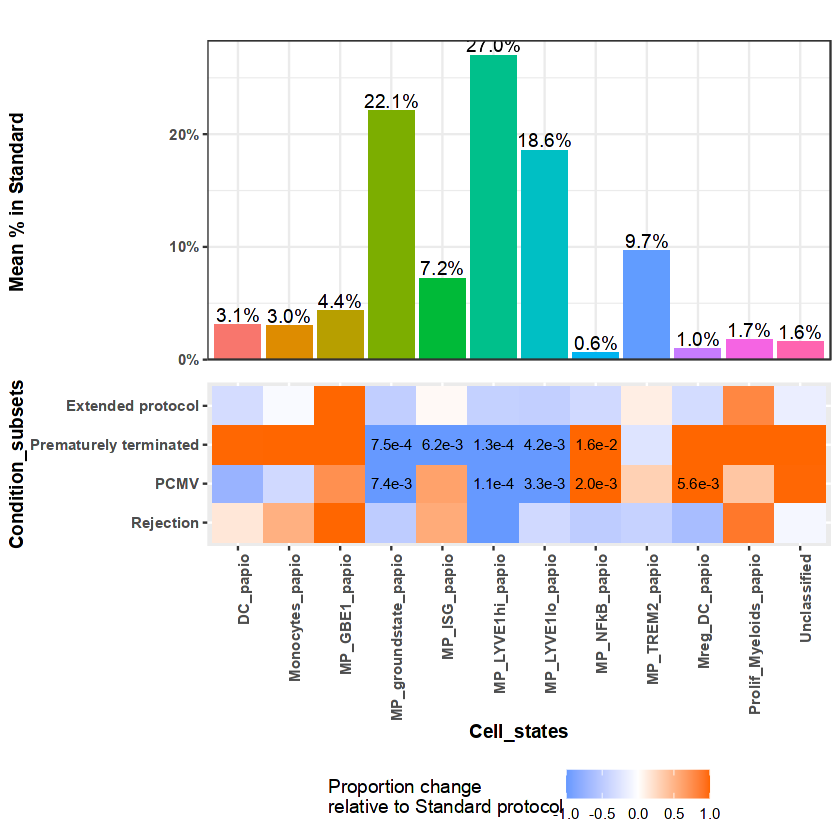

In [10]:
# Merge
plot_all <- ggarrange(
  p_ref_no_x_axis, p1,
  ncol = 1, nrow = 2,
  align = "v",
  heights = c(4, 5)  # You can adjust these numbers for desired proportions
)

# Print in RStudio/viewer
plot_all

# Save as PDF
ggsave("Final_CLR_Myeloids_baboon_Standard.pdf", plot = plot_all,
       width = 7, height = 8, units = "in", dpi = 400)
